
# MATLAB-like - state-based - Zeile für Zeile - Schritt für Schritt

At the top of the matplotlib hierarchy is the "state-machine environment" which is provided by the `matplotlib.pyplot` module. This is also called the **MATLAB-like interface**.

In the examples above, we used this kind of interface. At this level, most of the plotting related elements (lines, images, text, etc.) are handled by the `pyplot` module.

This interface is usually the easiest way to get started with plotting using matplotlib. It is designed to be compatible with [MATLAB](https://it.mathworks.com/products/matlab.html)'s plotting functions, so it is easier to get started with if you are familiar with MATLAB.

It also has a minumum of coding overhead for simple plots.


## .plot - Format/Colors/Lines to Simple scatterplot

We have already seen what `plt.plot()` creates if we you call it on an arbitrary sequence of numbers:


remember and watch out that most things here are now not in OO and use the stateful interface, implicitly managing the fig and ax

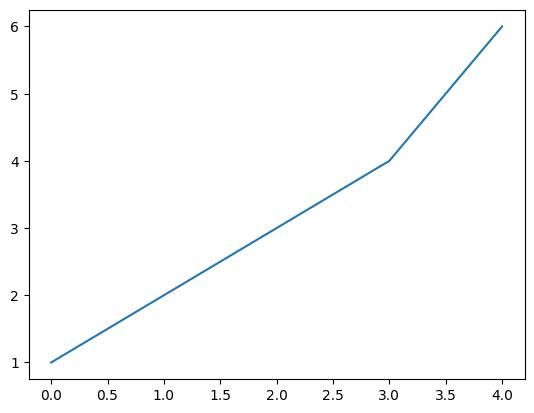

In [41]:
plt.plot(y);

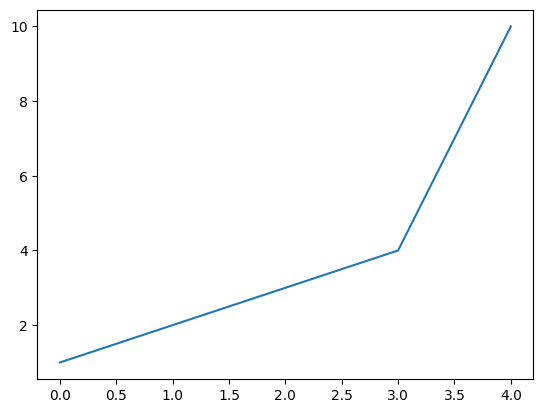

In [42]:
plt.plot([1, 2, 3, 4, 10]);

Matplotlib draws a **line chart** automatically, assuming the values of the X-axis start from zero, going up to as many items in the data.

Notice the line `matplotlib.lines.Line2D` in the above code output?

That's because Matplotlib returns the plot object itself besides drawing the plot.

If you only want to see the plot (e.g. in a non-interactive script), add `plt.show()` at the end and execute all the lines in one shot.

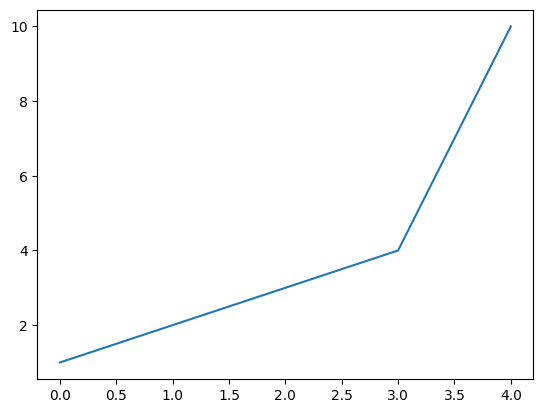

In [43]:
plt.plot([1, 2, 3, 4, 10])
plt.show()

Another possibility is to end the `plt.plot()` command with a semicolon:

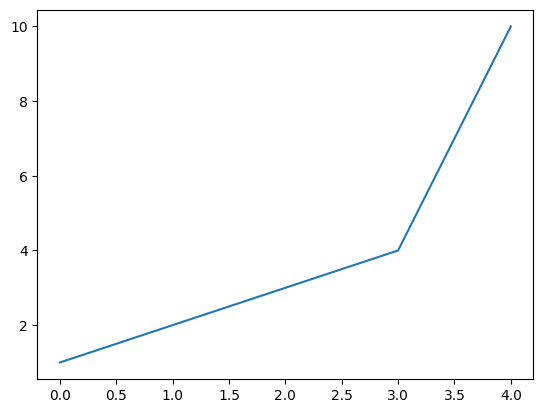

In [44]:
plt.plot([1, 2, 3, 4, 10]);

So, this is not a scatterplot yet, but a line chart. How to draw a real scatterplot?

Let's first focus a bit more about what arguments `plt.plot()` expects.

The three basic arguments are: `plt.plot(x, y, format)` (in this specific order!)

The `format` is a string representing a shorthand combination of `[marker][line][color]`.

Each of them is optional: if not provided, the value from the style cycle is used. Exception: if `line` is given, but no `marker`, the data will be a line without markers.

Commonly used markers are:

- `'.'` (point)
- `'o'` (circle)
- `'*'` (star)
- `'D'` (diamond)

Line styles are:

- `'-'` (solid)
- `'--'` (dashed)
- `'-.'` (dash-dot)
- `':'` (dotted)

Colors are single-letter abbreviations of color names, such as:

- `'b'` (blue)
- `'g'` (green)
- `'r'` (red)
- `'k'` (black)

**Example:** The format `'o-g'` has 3 characters standing for: *green circles with solid line*.
By omitting the `line` part, you will be left with green circles (`‘og’`).

Note that:

1. `format` is not necessarily a 3-character string, since some `line` styles may take up 2 characters (e.g. `'--'`, `'-.'`).
2. you can provide the combination in any order (e.g. `[color][marker][line]`), but the parsing may be ambiguous.

Few commonly used short hand format examples are:

- `'*--r'` : red stars with dashed lines
- `'s:k'` : black squares with dotted line ('k' = black)
- `'D-.b'` : blue diamonds with dash-dot line

For a complete list of colors, markers and linestyles, check out the `help(plt.plot)` command (also [online](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)).

Let's draw a scatterplot with green dots:

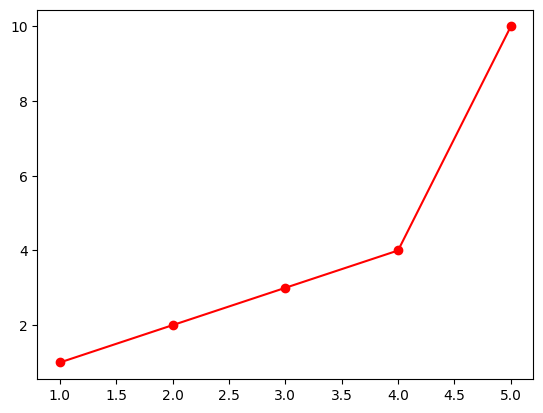

In [45]:
# 'og' stands for green circles
plt.plot([1, 2, 3, 4, 5], [1, 2, 3, 4, 10], 'o-r')
plt.show()

Now how to plot another set of 5 points of different color in the same figure?

Simply call `plt.plot()` again: it will add those point to the same picture.

You might wonder, why it does not draw these points in a new panel altogether? I will come to that in the next section.

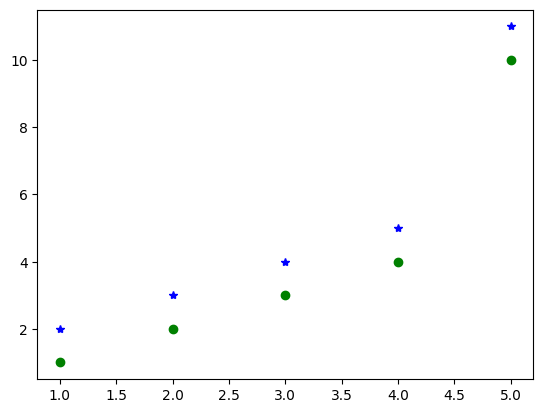

In [46]:
# Draw two sets of points
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])
plt.plot(xx, yy, "og")  # green dots
plt.plot(xx, yy+1, "*b")  # blue stars
plt.show()

Looks good. Now let’s add the basic plot features: Title, Legend, X and Y axis labels.

The `plt` object has corresponding methods to add each of these.

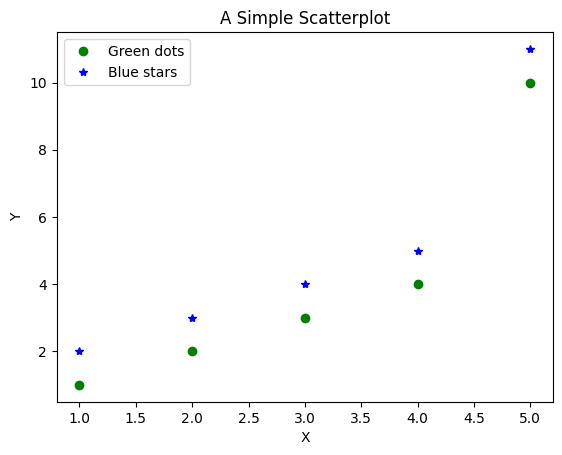

In [47]:
plt.plot(xx, yy, "og", label="Green dots") # we attach a label to be used by the legend
plt.plot(xx, yy+1, "*b", label="Blue stars")

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")  # legend text comes from the plot's label parameter
plt.show()

# other choices for loc are: 'upper right', 'lower right', 'center', 'right', 'center right' (similarly for left)

How to increase the size of the figure?

The easy way to do it is by setting the `figsize` inside `plt.figure()` method. We also set the x-y axis limits.

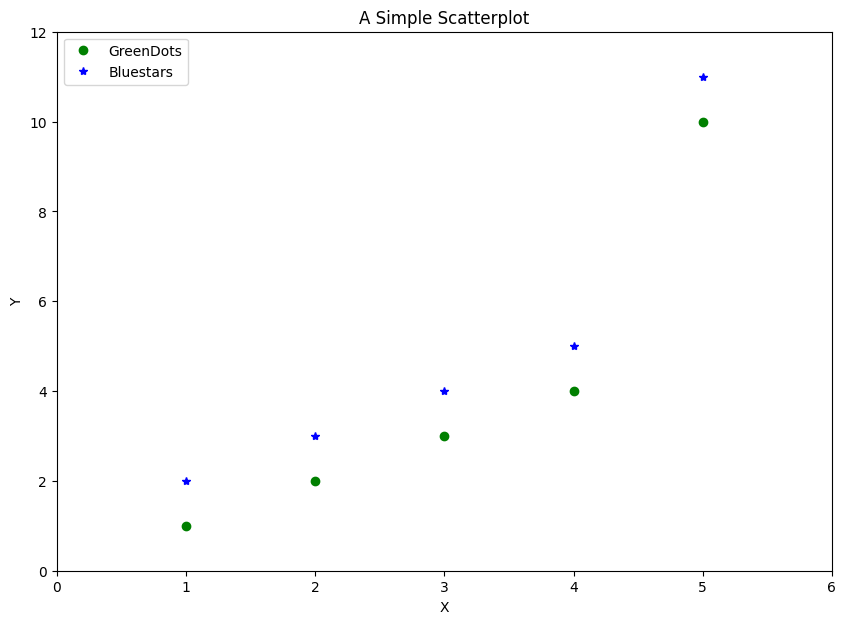

In [48]:
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])
plt.figure(figsize=(10, 7))  # (width, height) # durch das Modul deklariert
#plt.add_axes()

plt.plot(xx, yy, "og", label="GreenDots")  # green dots
plt.plot(xx, yy+1, "*b", label="Bluestars")  # blue stars

plt.xlim(0, 6) # x axis limits
#ax.set_xlim(0, 6) # x axis limits; Gegenüberstellung

plt.ylim(0, 12) # y axis limits

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")
plt.show()

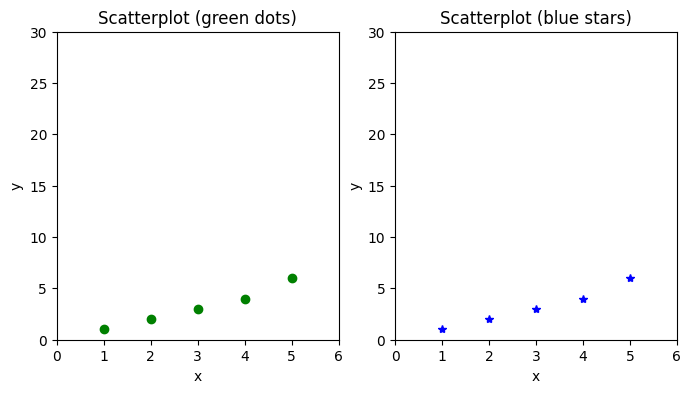

In [49]:
plt.figure(figsize=(8, 4), dpi=100)

# left hand subplot
plt.subplot(1, 2, 1) # (nRows, nColumns, axes number to plot)
plt.plot(x, y, "og")
plt.title("Scatterplot (green dots)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 30)

# right hand subplot
plt.subplot(1, 2, 2)
plt.plot(x, y, "*b")
plt.title("Scatterplot (blue stars)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 30)

plt.show()

Let’s breakdown the above piece of code.

In `plt.subplot(1,2,1)`, the first two values (1,2) specify the number of rows (1) and columns (2), and the third value (1) specifies the position of the current subplot. The subsequent `plt` functions will always draw on this current subplot.

You can get a reference to the current (subplot) axes with `plt.gca()` ("get current axis") and the current figure with `plt.gcf()` ("get current figure"). Likewise, `plt.cla()` and `plt.clf()` will clear the current axes and figure respectively.

This stateful interface may be quick and convenient for simpler plots. However, we realize it can lead to problems: for example, once the second panel is created, how can we add something back to the first?

The OO interface might look a but confusing because it has a mix of both `ax` and `plt` commands. However, there is a significant advantage with **the OO approach**, as it **provides more clear control over customization**.

Since `plt.subplots` returns all the axes as separate objects, you can avoid writing repetitive code by looping through the axes, like we did in one of the examples above.

Always remember: `plt.plot()` or `plt.{anything}` will always act on the plot in the *current* axes, whereas `ax.{anything}` will modify the plot inside that specific `ax`.

In the following example, we'll draw multiple plots using for-loops with OO syntax: the target is to have a figure with 4 panels arranged in a 2x2 matrix. The panels will share both X and Y axis.

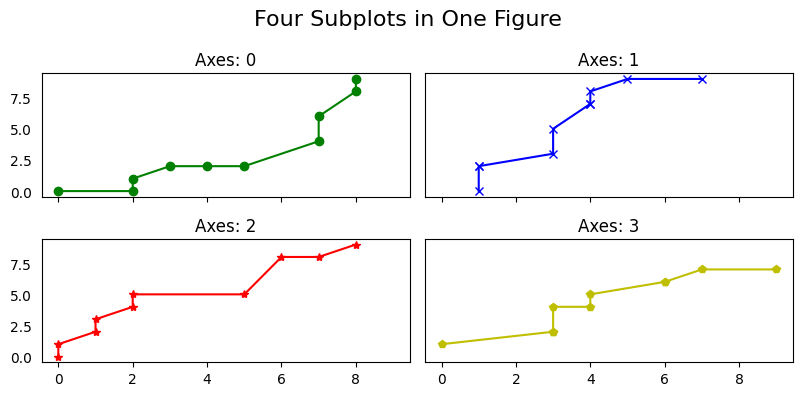

In [60]:
np.random.seed(100)

# create Figure and Subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 4), dpi=100,
                         sharex=True, sharey=True)

# define the colors and markers to use
colors = {0:'g', 1:'b', 2:'r', 3:'y'}
markers = {0:'o', 1:'x', 2:'*', 3:'p'}

# plot each axes
for i, ax in enumerate(axes.ravel()): # I use ravel() to obtain a 1D array from a 2x2 matrix
    # generate random data
    xvals = sorted(np.random.randint(0, 10, 10))
    yvals = sorted(np.random.randint(0, 10, 10))

    ax.plot(xvals, yvals, marker=markers[i], color=colors[i])
    ax.set_title(f'Axes: {i}')
    ax.yaxis.set_ticks_position('none')

plt.suptitle('Four Subplots in One Figure', fontsize=16)
plt.tight_layout()
plt.show()

Things to notice:

1. you can specify marker type, color, and line through dedicated arguments within `plot()`, instead of using the `fmt` string
1. Y axis ticks were switched off with `ax.yaxis.set_ticks_position("none")`

Another advantage of the OO interface is the possibility to set a dynamic title for each subplot.

You can actually get a reference to any specific element of the plot and use its methods to manipulate it.

`plt.suptitle()` adds a main title at figure level.
(`plt.title()` would have done the same for the current subplot)

So far you have learned the core essence creating and manipulating a plot using `matplotlib`.
Next, let’s see how to modify other components of the plot.

## .subplots(); .tight_layout() sharey:

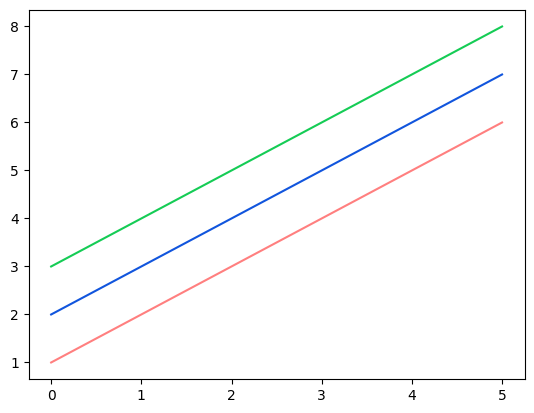

In [50]:
fig, ax = plt.subplots()

x = np.linspace(0, 5, 10)

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparant red
ax.plot(x, x+2, color="#1155dd") # bluish color
ax.plot(x, x+3, color="#15cc55") # greenish color
plt.show()

Let's add titles and x-y labels:

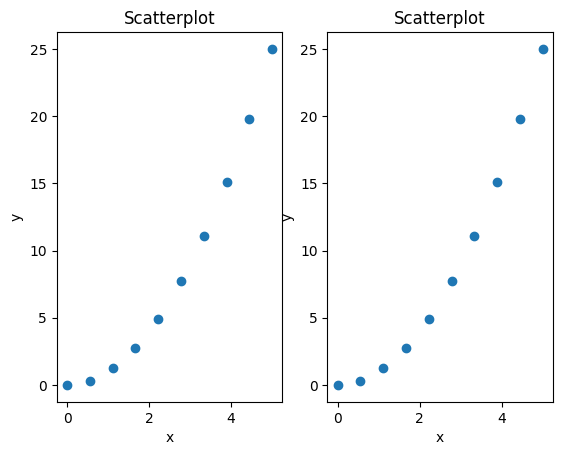

In [54]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

plt.show()

Quite good, but figure axes and labels overlap: we fix this with the `fig.tight_layout` method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

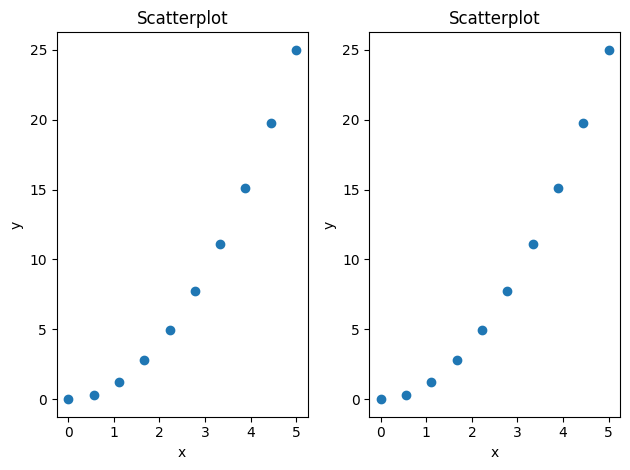

In [55]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

Better, but we notice that the y-axis labels of the right-hand panel are redundant: in the following example, we create two Axes sharing the y axis.

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

Thats sounds like a lot of functions to learn! It's actually quite easy to remember them.

The `ax1` and `ax2` objects, like `plt`, have equivalent `set_title`, `set_xlabel` and `set_ylabel` functions. In fact, `plt.title()` actually calls the current axes `set_title()` to do the job.

* `plt.xlabel()` → `ax.set_xlabel()`
* `plt.ylabel()` → `ax.set_ylabel()`
* `plt.xlim()` → `ax.set_xlim()`
* `plt.ylim()` → `ax.set_ylim()`
* `plt.title()` → `ax.set_title()`

Alternately, to save keystrokes, you can set multiple things in one go using the `ax.set()`:

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set(title="Scatterplot", xlabel="x", ylabel="y",
           xlim=(0, 6), ylim=(0, 30))

fig.tight_layout()
plt.show()

## plt.figure(figsize= , dpi=)

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the `Figure` object is created, using the `figsize` and `dpi` keyword arguments. `figsize` is a tuple of the width and height of the figure in inches, and `dpi` is the dots-per-inch (pixel per inch). To create an 800x400 pixel, 100 dots-per-inch figure, we can do:

In [ ]:
fig = plt.figure(figsize=(8, 4), dpi=100)

The same arguments can also be passed to layout managers, such as the `subplots` function:

## .saveFig()

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [ ]:
fig.savefig("filename.png", dpi=200, format="png")

In this case, the image format is inferred from the filename extension. Available formats include PNG, JPG, EPS, SVG, PDF.

You can also specify the DPI and explicitly set an output format: note that, if you do specify a format, then the literal filename is used, regardless of its extension (it's up to you to check its consistency with the format).